# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit_0pa_vs_1pa= best_fit = [13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]

best_fit_with_deviation = [ 1.38157246e+01 , 1.00042793e+01 , 8.00138681e-01 , 7.49924060e+00,3.99933604e-01 , 7.85947492e-01,  9.99634868e-01,  9.66081240e-01, 3.41367413e-01, -2.40188581e-04, -6.24286978e-05]

In [4]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [5]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [6]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit_0pa_vs_1pa=  [13.81561299, 10.00055693,  0.80008266,  7.49954817,
                                   0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]

best_fit_with_deviation = [ 1.38157246e+01 , 1.00042793e+01 , 8.00138681e-01 , 7.49924060e+00,
                           3.99933604e-01 , 7.85947492e-01,  9.99634868e-01,  9.66081240e-01,
                           3.41367413e-01, -2.40188581e-04, -6.24286978e-05]

#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

der_order = 8
Ndelta=16

True


## Fisher at Best FIT 0PA With Deviation

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000214.0649443562), 10.0042793, 0.800138681, 7.4992406, 0.399933604, 1.0, 0.4, 0.785947492, 0.999634868, 1, 1.0471975511965976, 0.96608124, 0.5, 0.341367413, 0.0, False, False, False, True, -0.000240188581, -6.24286978e-05, 0.0, 0.0, 0.0, 0.0)
SNR:  136.8833822982727
Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000214.0649443562), 10.0042793, 0.800138681, 7.4992406, 0.399933604, 1.0, 0.4, 0.785947492, 0.999634868, 1, 1.0471975511965976, 0.96608124, 0.5, 0.341367413, 0.0, False, False, False, True, -0.000240188581, -6.24286978e-05, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.8833822982727
calculating stable deltas...
Gamma_ii for m1: 22260.760609820158
Gamma_ii for m1: 22260.76060945666
Gamma_ii for m1: 22260.76060948037
Gamma_ii for m1: 22260.760610138215
Gamma_ii for m1: 22260.760609642097
Gamma_ii for m1: 2226

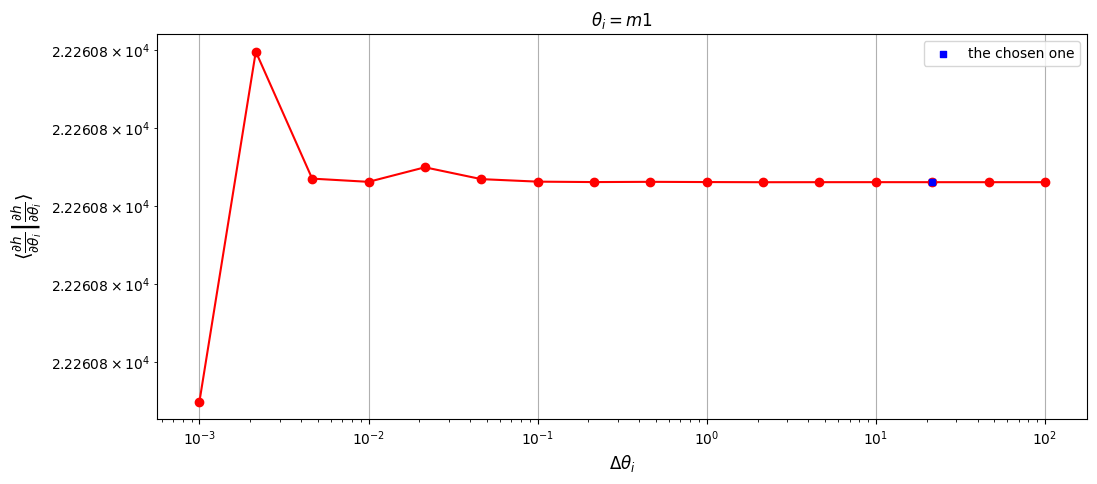

Gamma_ii for m2: 14188645022963.383
Gamma_ii for m2: 14188645022163.34
Gamma_ii for m2: 14188645023154.629
Gamma_ii for m2: 14188645022919.904
Gamma_ii for m2: 14188645023134.475
Gamma_ii for m2: 14188645020107.064
Gamma_ii for m2: 14188645018545.752
Gamma_ii for m2: 14188645005190.914
Gamma_ii for m2: 14188645128539.203
Gamma_ii for m2: 14188645012704.092
Gamma_ii for m2: 14188645275461.678
Gamma_ii for m2: 14188645099980.928
Gamma_ii for m2: 14188646881410.148
Gamma_ii for m2: 14188643139085.908
Gamma_ii for m2: 14188648102002.123
Gamma_ii for m2: 14188647161297.354
[np.float64(5.638614310952841e-11), np.float64(6.986495615911899e-11), np.float64(1.6543130721491238e-11), np.float64(1.5122678180343843e-11), np.float64(2.1336851770974506e-10), np.float64(1.1003957727881932e-10), np.float64(9.41234197186492e-10), np.float64(8.693450850666202e-09), np.float64(8.163930468653609e-09), np.float64(1.8518863558589477e-08), np.float64(1.2367689005078848e-08), np.float64(1.2555314369245028e-07)

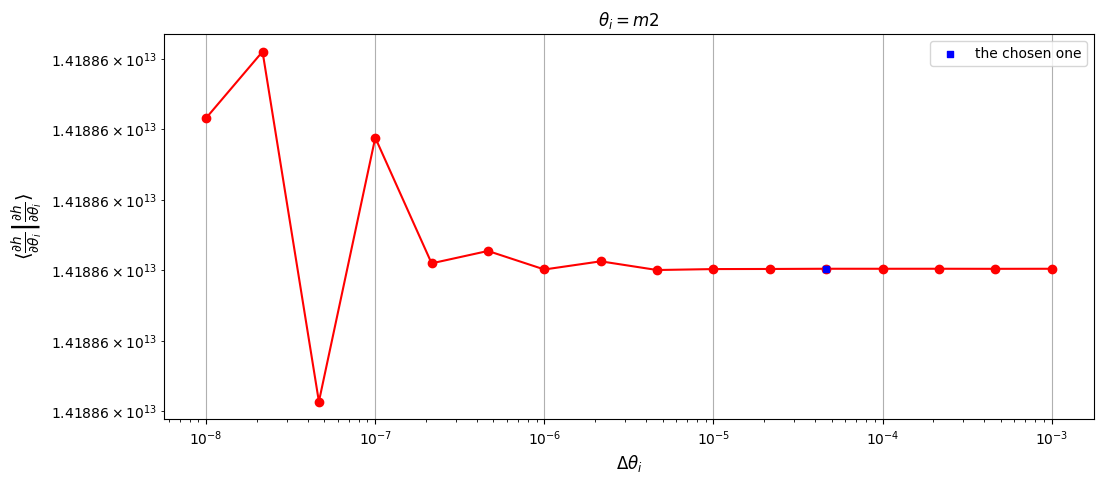

Gamma_ii for a: 1817404421784763.5
Gamma_ii for a: 1817404320501787.2
Gamma_ii for a: 1817404393802694.5
Gamma_ii for a: 1817404736280905.0
Gamma_ii for a: 1817403466665543.8
Gamma_ii for a: 1817401347699686.2
Gamma_ii for a: 1817395049370092.0
Gamma_ii for a: 1817405652772450.5
Gamma_ii for a: 1817433379870458.0
Gamma_ii for a: 1817408575722917.8
Gamma_ii for a: 1817428217936719.0
Gamma_ii for a: 1817708823985638.5
Gamma_ii for a: 1816982629618858.0
Gamma_ii for a: 1817069639097230.5
Gamma_ii for a: 1814161874375601.8
Gamma_ii for a: 1819607223049634.5
[np.float64(5.572946818022071e-08), np.float64(4.033274459991092e-08), np.float64(1.8844355561702755e-07), np.float64(6.985875093434313e-07), np.float64(1.1659317080302647e-06), np.float64(3.46558091287472e-06), np.float64(5.8343619336302385e-06), np.float64(1.5256183976040055e-05), np.float64(1.3648085450671738e-05), np.float64(1.0807697166465984e-05), np.float64(0.00015437348667550786), np.float64(0.00039967050589406636), np.float64(4

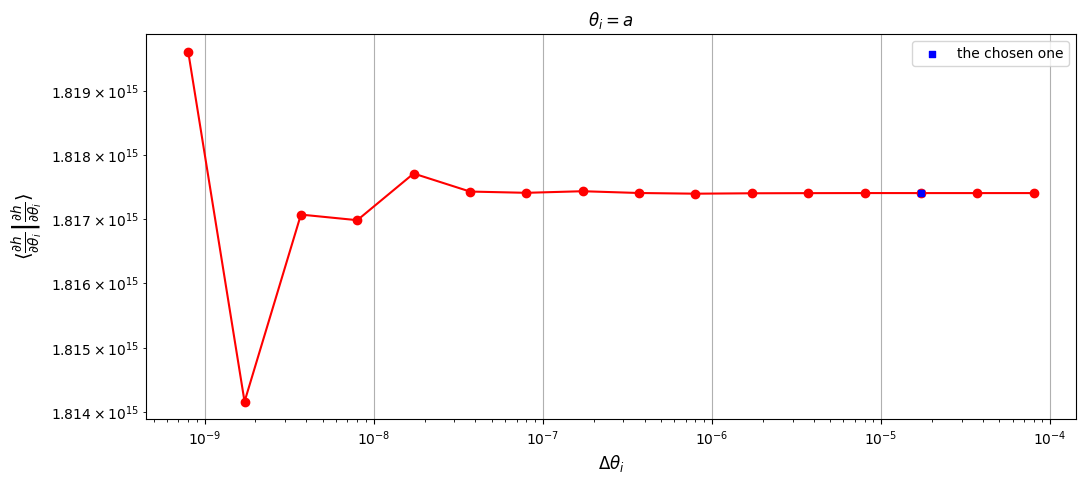

Gamma_ii for p0: 1174027391915628.0
Gamma_ii for p0: 1174027389792262.2
Gamma_ii for p0: 1174027416328505.0
Gamma_ii for p0: 1174027443960094.2
Gamma_ii for p0: 1174027437127990.5
Gamma_ii for p0: 1174027189617547.0
Gamma_ii for p0: 1174027696615898.2
Gamma_ii for p0: 1174029009622628.5
Gamma_ii for p0: 1174028348741715.8
Gamma_ii for p0: 1174023047436281.8
Gamma_ii for p0: 1174036076297910.0
Gamma_ii for p0: 1174030401197339.0
Gamma_ii for p0: 1174058784835292.5
Gamma_ii for p0: 1173866469362801.8
Gamma_ii for p0: 1173781537481857.5
Gamma_ii for p0: 1173604535825016.0
[np.float64(1.8086168759450476e-09), np.float64(2.2602745371130995e-08), np.float64(2.3535726862394547e-08), np.float64(5.819373154270819e-09), np.float64(2.108217302706843e-07), np.float64(4.318453071519594e-07), np.float64(1.118376734721439e-06), np.float64(5.629173379487046e-07), np.float64(4.5155037165381714e-06), np.float64(1.1097496824232124e-05), np.float64(4.833861682978762e-06), np.float64(2.417565314455861e-05)

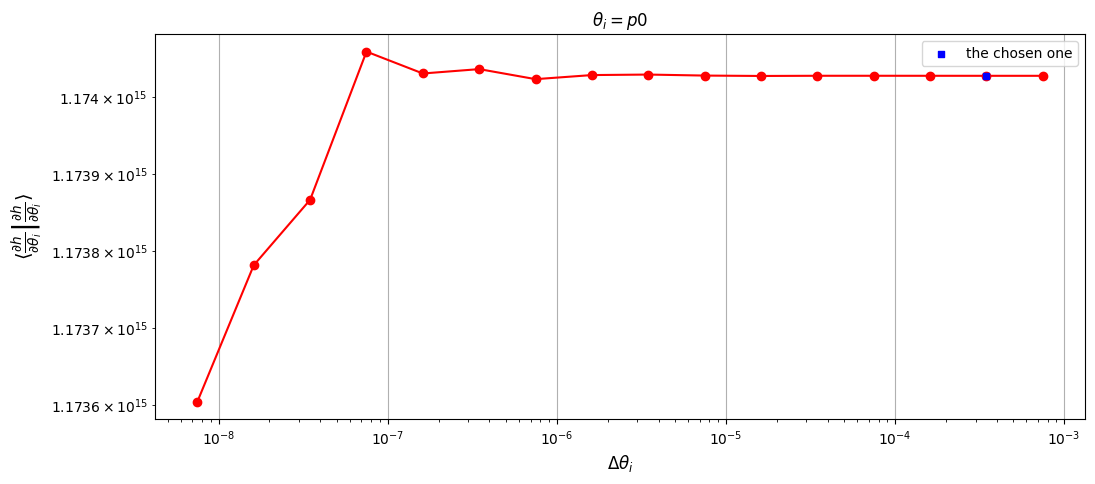

Gamma_ii for e0: 3818532055182674.5
Gamma_ii for e0: 3818531832866138.0
Gamma_ii for e0: 3818530445307738.0
Gamma_ii for e0: 3818531493264425.5
Gamma_ii for e0: 3818535871893164.0
Gamma_ii for e0: 3818521522466227.0
Gamma_ii for e0: 3818531786294908.0
Gamma_ii for e0: 3818504324603437.0
Gamma_ii for e0: 3818392892147441.0
Gamma_ii for e0: 3818562598911831.0
Gamma_ii for e0: 3818828488904343.0
Gamma_ii for e0: 3817903681752648.0
Gamma_ii for e0: 3816953252505134.5
Gamma_ii for e0: 3819886071395192.0
Gamma_ii for e0: 3810899585391918.0
Gamma_ii for e0: 3840742974274603.0
[np.float64(5.8220422463555116e-08), np.float64(3.6337497366429294e-07), np.float64(2.744397131065985e-07), np.float64(1.1466773877206374e-06), np.float64(3.7578489089495275e-06), np.float64(2.687899238612575e-06), np.float64(7.191740308910604e-06), np.float64(2.9183077578308362e-05), np.float64(4.444257753908788e-05), np.float64(6.962606288408786e-05), np.float64(0.00024222904210890352), np.float64(0.0002490020664753272

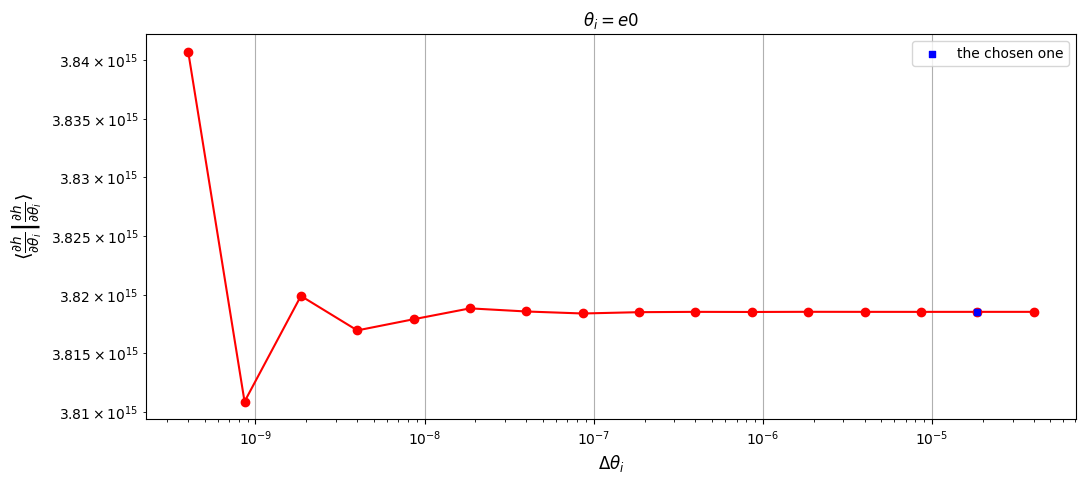

Gamma_ii for qS: 58813.45318883948
Gamma_ii for qS: 58813.45328574292
Gamma_ii for qS: 58813.45328595566
Gamma_ii for qS: 58813.45328595664
Gamma_ii for qS: 58813.453285956464
Gamma_ii for qS: 58813.45328595895
Gamma_ii for qS: 58813.453285957905
Gamma_ii for qS: 58813.45328594197
Gamma_ii for qS: 58813.4532859662
Gamma_ii for qS: 58813.45328598807
Gamma_ii for qS: 58813.4532859246
Gamma_ii for qS: 58813.45328581922
Gamma_ii for qS: 58813.45328625638
Gamma_ii for qS: 58813.45328713661
Gamma_ii for qS: 58813.45328686523
Gamma_ii for qS: 58813.453284729476
[np.float64(1.6476407877265486e-09), np.float64(3.617105217222381e-12), np.float64(1.6701183539401235e-14), np.float64(2.969099295893562e-15), np.float64(4.2309664966481466e-14), np.float64(1.7814595775360934e-14), np.float64(2.709303107503543e-13), np.float64(4.119625273051635e-13), np.float64(3.7187968681046877e-13), np.float64(1.079143881587232e-12), np.float64(1.791851425075946e-12), np.float64(7.433016374760965e-12), np.float64(1.

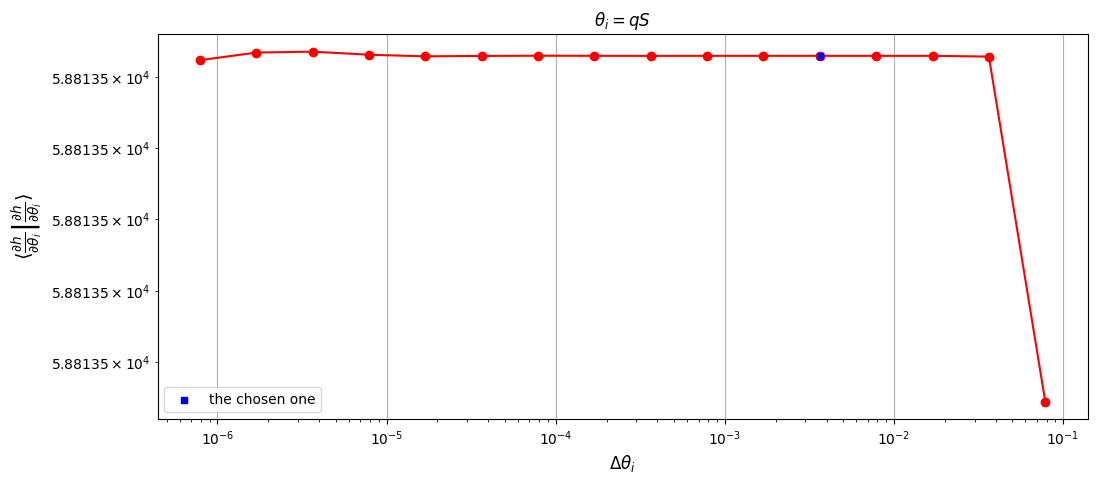

Gamma_ii for phiS: 1114712.7346773907
Gamma_ii for phiS: 1114712.7346405047
Gamma_ii for phiS: 1114712.7346404232
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.7346404227
Gamma_ii for phiS: 1114712.7346404234
Gamma_ii for phiS: 1114712.7346404244
Gamma_ii for phiS: 1114712.7346404248
Gamma_ii for phiS: 1114712.7346404337
Gamma_ii for phiS: 1114712.7346404374
Gamma_ii for phiS: 1114712.7346404179
Gamma_ii for phiS: 1114712.7346403843
[np.float64(3.3090105409189914e-11), np.float64(7.310468674706683e-14), np.float64(2.0887053356304813e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0887053356304818e-16), np.float64(6.266116006891441e-16), np.float64(8.354821342521914e-16), np.float64(4.1774106712609557e-16), np.float64(7.937080275395753e-15), np.float64(3.3419285370087267e-15), np.float

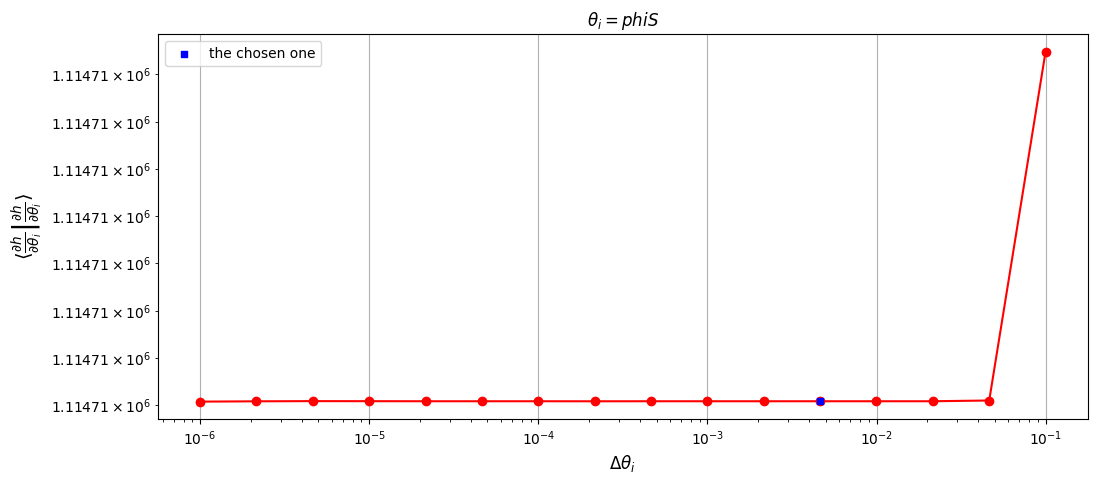

Gamma_ii for dev0p: 1161709945637358.5
Gamma_ii for dev0p: 1161710066899326.2
Gamma_ii for dev0p: 1161709346964758.2
Gamma_ii for dev0p: 1161709179215319.2
Gamma_ii for dev0p: 1161712441424544.5
Gamma_ii for dev0p: 1161693699257695.0
Gamma_ii for dev0p: 1161714576391930.0
Gamma_ii for dev0p: 1161717667977933.5
Gamma_ii for dev0p: 1161770883544472.2
Gamma_ii for dev0p: 1161491219994563.0
Gamma_ii for dev0p: 1161280140541242.5
Gamma_ii for dev0p: 1160451562213620.5
Gamma_ii for dev0p: 1159695040908038.2
Gamma_ii for dev0p: 1163477543340550.5
Gamma_ii for dev0p: 1159807708639955.0
Gamma_ii for dev0p: 1176849218886086.0
[np.float64(1.0438229916837637e-07), np.float64(6.197200443303656e-07), np.float64(1.4439882373427313e-07), np.float64(2.8081038895044724e-06), np.float64(1.6133484120191034e-05), np.float64(1.7970966930483482e-05), np.float64(2.6612197513369694e-06), np.float64(4.580556053909137e-05), np.float64(0.00024077973651024165), np.float64(0.00018176445626816743), np.float64(0.0007

/home/svu/e1583490/scratch/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


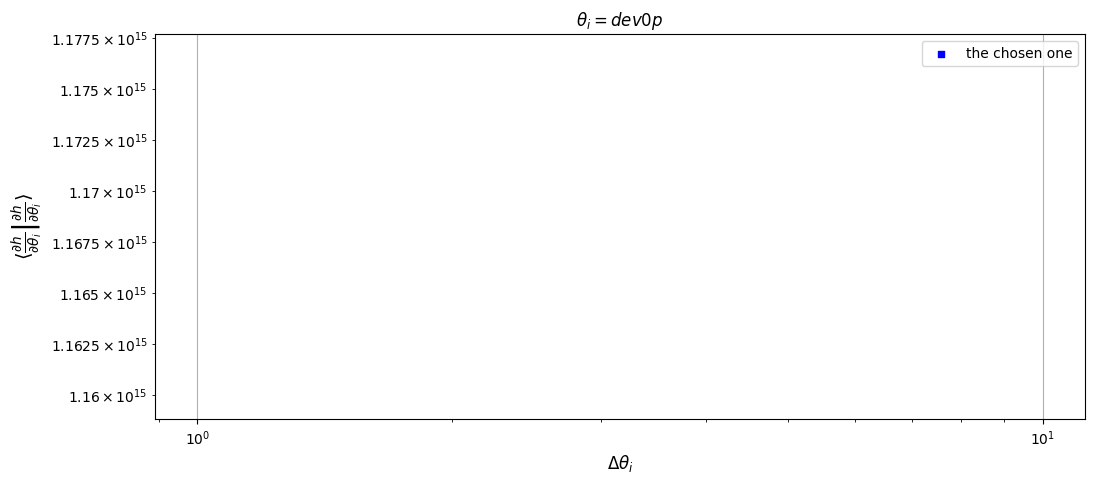

Gamma_ii for dev0e: 14332420246962.438
Gamma_ii for dev0e: 14332406454368.521
Gamma_ii for dev0e: 14332023739855.584
Gamma_ii for dev0e: 14332996826263.426
Gamma_ii for dev0e: 14332322458790.543
Gamma_ii for dev0e: 14332961173769.203
Gamma_ii for dev0e: 14339290768670.008
Gamma_ii for dev0e: 14300638533936.584
Gamma_ii for dev0e: 14395616704831.617
Gamma_ii for dev0e: 14334960308864.959
Gamma_ii for dev0e: 14520473549886.418
Gamma_ii for dev0e: 14319891126061.39
Gamma_ii for dev0e: 13827153030676.03
Gamma_ii for dev0e: 16207628126379.2
Gamma_ii for dev0e: 9943429785033.293
Gamma_ii for dev0e: 11489602040679.803
[np.float64(9.623362245501792e-07), np.float64(2.6703452344501657e-05), np.float64(6.789134328549753e-05), np.float64(4.705221186739334e-05), np.float64(4.456266719183406e-05), np.float64(0.00044141617621941615), np.float64(0.0027028327890184006), np.float64(0.006597714626783275), np.float64(0.004231361277585635), np.float64(0.012775977338763178), np.float64(0.014007258997938797

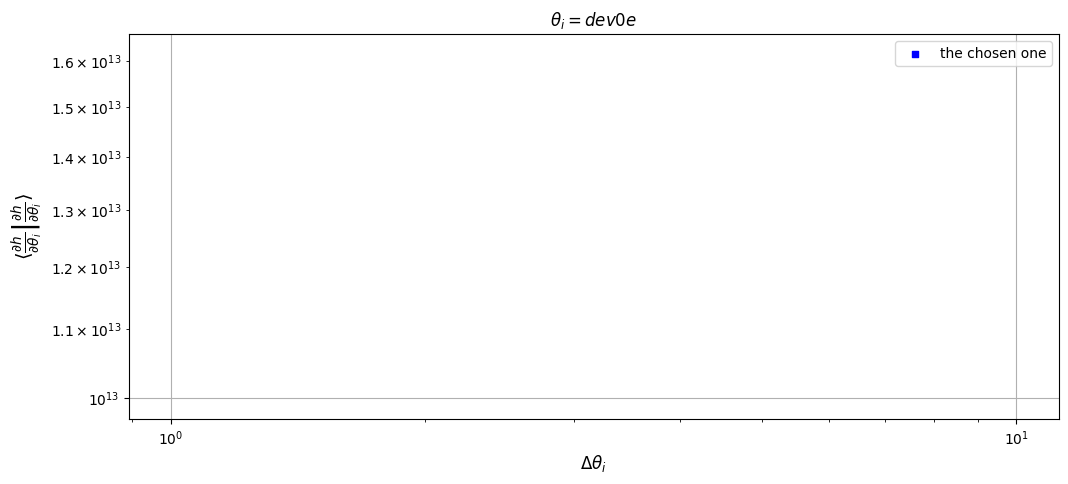

stable deltas: {'m1': 21.548958789739252, 'm2': 4.643575108722344e-05, 'a': 1.7238465311827528e-05, 'p0': 0.0003480839142953559, 'e0': 1.856327350512915e-05, 'qS': 0.0036480451026731702, 'phiS': 0.004639894040998785, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': -1.1148566355308984e-05, 'dev0e': -2.8976834660546715e-06}
Time taken to compute stable deltas is 308.07857155799866 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is not positive semi-definite. Try lowering inspiral error tolerance or increasing the derivative order.
Time taken to compute FM is 20.698912858963013 seconds


In [7]:
logm1_bf = best_fit_with_deviation[0]
m1_bf = np.exp(logm1_bf)
m2_bf = best_fit_with_deviation[1]
a_bf = best_fit_with_deviation[2]
p0_bf = best_fit_with_deviation[3]
e0_bf  = best_fit_with_deviation[4]
qS_bf = best_fit_with_deviation[5]
phiS_bf = best_fit_with_deviation[6]
Phi_phi0_bf = best_fit_with_deviation[7]
Phi_r0_bf = best_fit_with_deviation[8]
dev_0_p_bf =best_fit_with_deviation[9]
dev_0_e_bf =best_fit_with_deviation[10]

evolve_1PA_bf = False
deviation_included_bf = True

pars_list_com = [m1_bf, m2_bf, a_bf, p0_bf, e0_bf, xI0, dist, qS_bf, phiS_bf, qK, phiK, Phi_phi0_bf, Phi_theta0, Phi_r0_bf,\
             chi2,evolve_1PA_bf,evolve_primary,evolve_2PA,deviation_included_bf,dev_0_p_bf,dev_0_e_bf,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_bf,"dev0p":dev_0_p_bf,"dev0e":dev_0_e_bf,
                    "dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

add_args_bf = [chi2, evolve_1PA_bf, evolve_primary, evolve_2PA,deviation_included_bf,dev_0_p_bf,dev_0_e_bf,dev_1_p,dev_1_e,dev_2_p,dev_2_e]


sef_bf = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_bf = {
    'm1': m1_bf,
    'm2': m2_bf,
    'a': a_bf,
    'p0': p0_bf,
    'e0': e0_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_bf,
    'phiS': phiS_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_bf
}


Fisher_bf = sef_bf(wave_params = param_dict_bf,param_names=param_names, add_param_args=add_param_args_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

## Fisher Best FIT Point 0PA without Deviation

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000102.437282066), 10.00055693, 0.80008266, 7.49954817, 0.39998251, 1.0, 0.4, 0.78536073, 0.99998866, 1, 1.0471975511965976, 0.90006928, 0.5, 0.39977347, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  136.81223981118265
Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000102.437282066), 10.00055693, 0.80008266, 7.49954817, 0.39998251, 1.0, 0.4, 0.78536073, 0.99998866, 1, 1.0471975511965976, 0.90006928, 0.5, 0.39977347, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.81223981118265
calculating stable deltas...
Gamma_ii for m1: 22245.19474228892
Gamma_ii for m1: 22245.194744581135
Gamma_ii for m1: 22245.19474446373
Gamma_ii for m1: 22245.194744598924
Gamma_ii for m1: 22245.194744881
Gamma_ii for m1: 22245.19474579063
Gamma_ii for m1: 22245.194747430978
Gamma_i

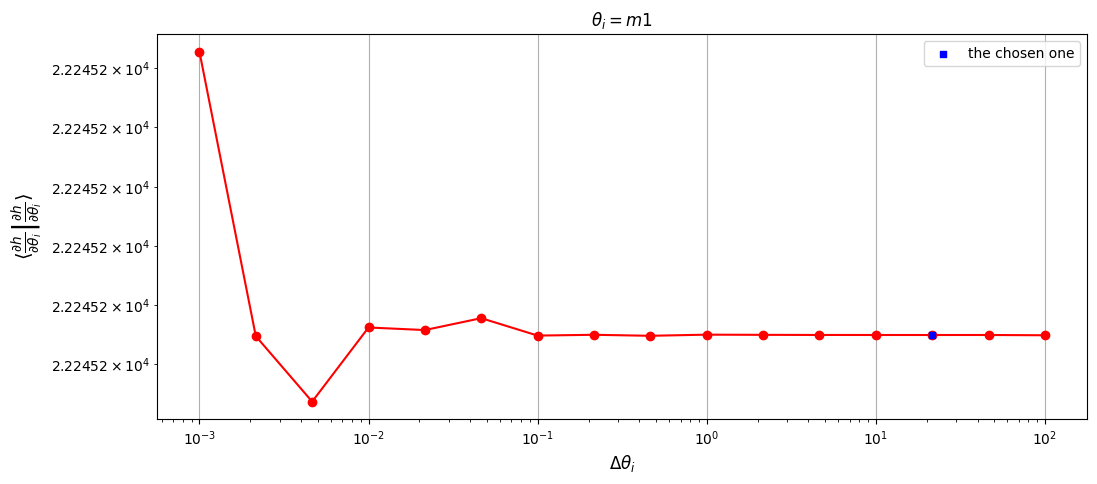

Gamma_ii for m2: 14185105601639.025
Gamma_ii for m2: 14185105601677.277
Gamma_ii for m2: 14185105601088.834
Gamma_ii for m2: 14185105600720.535
Gamma_ii for m2: 14185105599862.812
Gamma_ii for m2: 14185105595856.72
Gamma_ii for m2: 14185105606379.188
Gamma_ii for m2: 14185105605771.629
Gamma_ii for m2: 14185105630257.54
Gamma_ii for m2: 14185105554593.23
Gamma_ii for m2: 14185105704243.127
Gamma_ii for m2: 14185106111147.477
Gamma_ii for m2: 14185106989152.148
Gamma_ii for m2: 14185108103213.994
Gamma_ii for m2: 14185107120326.615
Gamma_ii for m2: 14185101581206.098
[np.float64(2.696628012446873e-12), np.float64(4.148318496337678e-11), np.float64(2.596377062616243e-11), np.float64(6.046642728259248e-11), np.float64(2.8241536658318045e-10), np.float64(7.417968599502663e-10), np.float64(4.2830741669120663e-11), np.float64(1.7261704490955874e-09), np.float64(5.334067364006988e-09), np.float64(1.054979071742912e-08), np.float64(2.8685322931042865e-08), np.float64(6.189623191044249e-08), np

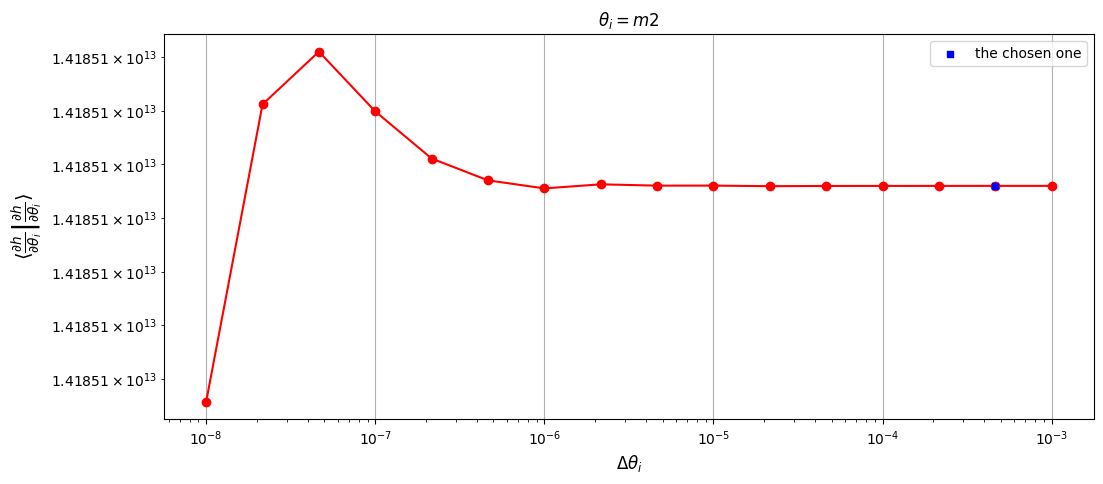

Gamma_ii for a: 1815422315399850.8
Gamma_ii for a: 1815422371452916.0
Gamma_ii for a: 1815422373274389.2
Gamma_ii for a: 1815422775922959.0
Gamma_ii for a: 1815422135239822.2
Gamma_ii for a: 1815423649117716.0
Gamma_ii for a: 1815419558805866.2
Gamma_ii for a: 1815429235207526.5
Gamma_ii for a: 1815380499849717.2
Gamma_ii for a: 1815337586982903.8
Gamma_ii for a: 1815337705430193.0
Gamma_ii for a: 1815281203805409.5
Gamma_ii for a: 1815800935458867.5
Gamma_ii for a: 1813072665628914.5
Gamma_ii for a: 1816678637420985.2
Gamma_ii for a: 1820915066207415.2
[np.float64(3.087604633027613e-08), np.float64(1.0033330407373449e-09), np.float64(2.217932787283083e-07), np.float64(3.5291138315076455e-07), np.float64(8.338978587646661e-07), np.float64(2.2530945146589123e-06), np.float64(5.330090246753058e-06), np.float64(2.68458088060792e-05), np.float64(2.3639055964693215e-05), np.float64(6.524807417137338e-08), np.float64(3.112554939975941e-05), np.float64(0.0002862272197952468), np.float64(0.001

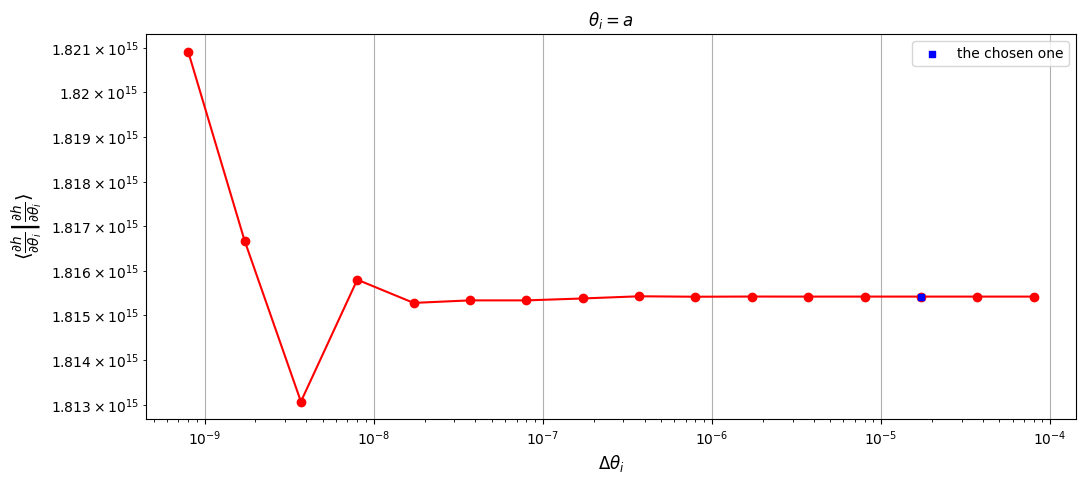

Gamma_ii for p0: 1172871398523672.8
Gamma_ii for p0: 1172871397668811.0
Gamma_ii for p0: 1172871378377061.8
Gamma_ii for p0: 1172871270560472.5
Gamma_ii for p0: 1172871306733653.5
Gamma_ii for p0: 1172871121758617.5
Gamma_ii for p0: 1172871591537973.5
Gamma_ii for p0: 1172871487924324.8
Gamma_ii for p0: 1172872601095881.2
Gamma_ii for p0: 1172874499848679.0
Gamma_ii for p0: 1172876040401466.8
Gamma_ii for p0: 1172860649167360.8
Gamma_ii for p0: 1172820692841609.0
Gamma_ii for p0: 1172938154164456.5
Gamma_ii for p0: 1173046863093074.0
Gamma_ii for p0: 1172346420903843.8
[np.float64(7.288623046815838e-10), np.float64(1.6448307636848115e-08), np.float64(9.192533908557448e-08), np.float64(3.0841560188508e-08), np.float64(1.577113056741018e-07), np.float64(4.0053775655354013e-07), np.float64(8.834185997083875e-08), np.float64(9.49098440410238e-07), np.float64(1.6188882936707822e-06), np.float64(1.313483040562991e-06), np.float64(1.3122815670324153e-05), np.float64(3.4068571603166756e-05), n

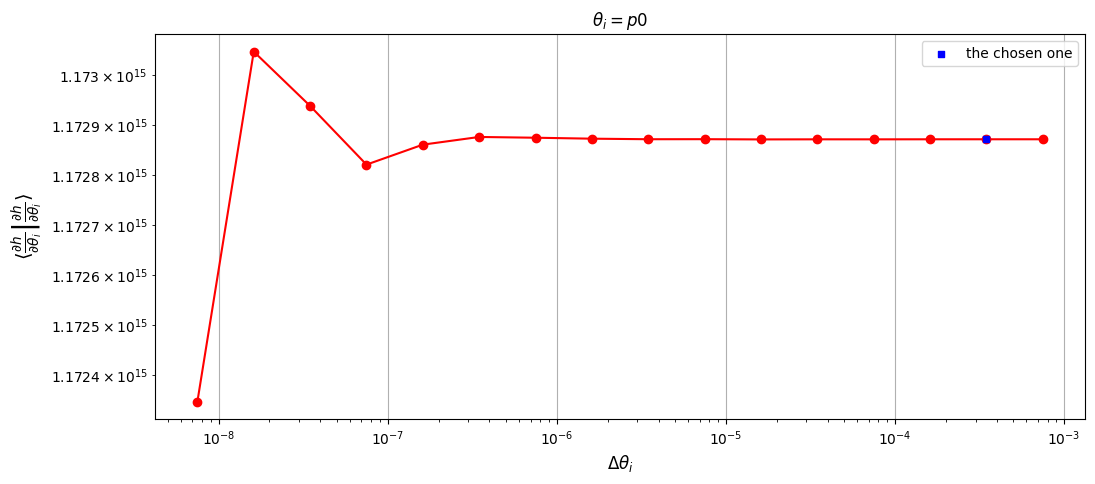

Gamma_ii for e0: 3817398277458968.0
Gamma_ii for e0: 3817397829517224.0
Gamma_ii for e0: 3817398372111420.5
Gamma_ii for e0: 3817400261606632.5
Gamma_ii for e0: 3817393325224320.5
Gamma_ii for e0: 3817401199265938.0
Gamma_ii for e0: 3817399573638052.0
Gamma_ii for e0: 3817413790253499.5
Gamma_ii for e0: 3817399277427204.0
Gamma_ii for e0: 3817523690559258.0
Gamma_ii for e0: 3817462126796173.5
Gamma_ii for e0: 3816939405672211.5
Gamma_ii for e0: 3818340791387627.0
Gamma_ii for e0: 3815255597841037.0
Gamma_ii for e0: 3822609433953081.0
Gamma_ii for e0: 3817136137306638.0
[np.float64(1.1734216972000793e-07), np.float64(1.4213716872307687e-07), np.float64(4.949691105236019e-07), np.float64(1.8170467963482382e-06), np.float64(2.0626707035703055e-06), np.float64(4.258469292096522e-07), np.float64(3.7241483969585413e-06), np.float64(3.8017574900577722e-06), np.float64(3.2590009162660564e-05), np.float64(1.6126882478377785e-05), np.float64(0.00013694771344423325), np.float64(0.0003670143111836

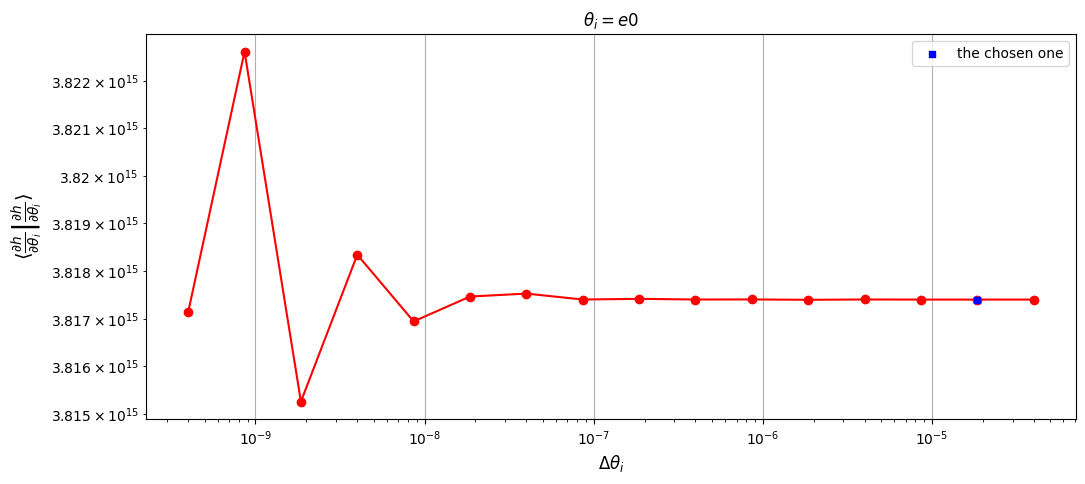

Gamma_ii for qS: 57457.0008828078
Gamma_ii for qS: 57457.000978979675
Gamma_ii for qS: 57457.00097919067
Gamma_ii for qS: 57457.00097919101
Gamma_ii for qS: 57457.00097919114
Gamma_ii for qS: 57457.00097918949
Gamma_ii for qS: 57457.0009791986
Gamma_ii for qS: 57457.00097919772
Gamma_ii for qS: 57457.00097918372
Gamma_ii for qS: 57457.00097919098
Gamma_ii for qS: 57457.000979077384
Gamma_ii for qS: 57457.00097921636
Gamma_ii for qS: 57457.0009792472
Gamma_ii for qS: 57457.00097886813
Gamma_ii for qS: 57457.000978284734
Gamma_ii for qS: 57457.00097246381
[np.float64(1.6738060537052447e-09), np.float64(3.6722329961169025e-12), np.float64(5.951755261129466e-15), np.float64(2.2793956319219183e-15), np.float64(2.874571158034946e-14), np.float64(1.5854462950921506e-13), np.float64(1.532260397014003e-14), np.float64(2.4364206643435204e-13), np.float64(1.2637982448100449e-13), np.float64(1.977122444514854e-12), np.float64(2.4188186647400806e-12), np.float64(5.366710382264258e-13), np.float64(6

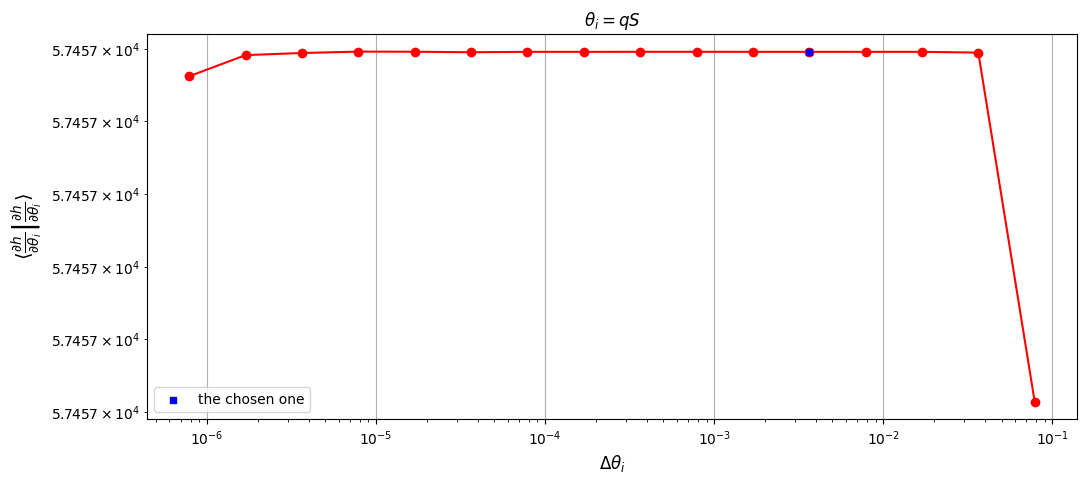

Gamma_ii for phiS: 1108794.0786808021
Gamma_ii for phiS: 1108794.0786439069
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.0786438254
Gamma_ii for phiS: 1108794.078643825
Gamma_ii for phiS: 1108794.0786438237
Gamma_ii for phiS: 1108794.0786438235
Gamma_ii for phiS: 1108794.0786438263
Gamma_ii for phiS: 1108794.0786438233
Gamma_ii for phiS: 1108794.078643833
Gamma_ii for phiS: 1108794.0786438105
Gamma_ii for phiS: 1108794.0786438813
[np.float64(3.327513722033128e-11), np.float64(7.349491384236676e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4.199709362420959e-16), np.float64(1.0499273406052409e-15), np.float64(2.0998546812104821e-16), np.float64(2.5198256174525723e-15), np.float64(2.729811085573627e-15), np.float64(8.819389661083949e-15), np.float64(2.036859040774

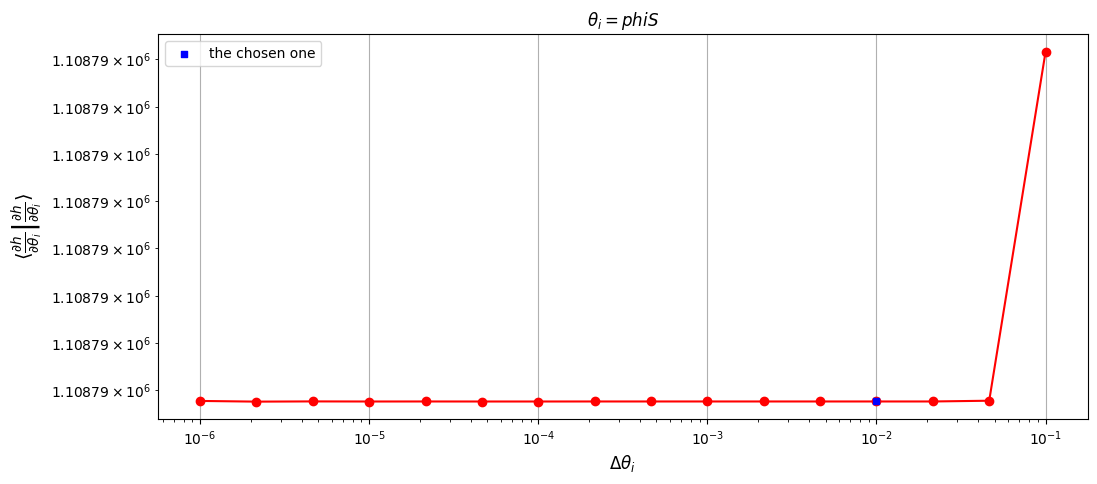

stable deltas: {'m1': 21.546553844659197, 'm2': 0.0004641847337619687, 'a': 1.723725837596985e-05, 'p0': 0.0003480981904301315, 'e0': 1.8565543520564136e-05, 'qS': 0.0036453215947259815, 'phiS': 0.009999886600000002, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 225.41859650611877 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 15.192763328552246 seconds


In [8]:
logm1_0v1_bf = best_fit_0pa_vs_1pa[0]
m1_0v1_bf = np.exp(logm1_0v1_bf)
m2_0v1_bf = best_fit_0pa_vs_1pa[1]
a_0v1_bf = best_fit_0pa_vs_1pa[2]
p0_0v1_bf = best_fit_0pa_vs_1pa[3]
e0_0v1_bf  = best_fit_0pa_vs_1pa[4]
qS_0v1_bf = best_fit_0pa_vs_1pa[5]
phiS_0v1_bf = best_fit_0pa_vs_1pa[6]
Phi_phi0_0v1_bf = best_fit_0pa_vs_1pa[7]
Phi_r0_0v1_bf = best_fit_0pa_vs_1pa[8]

evolve_1PA_0v1_bf = False
deviation_included_0v1_bf = True

pars_list_com = [m1_0v1_bf, m2_0v1_bf, a_0v1_bf, p0_0v1_bf, e0_0v1_bf, xI0, dist, qS_0v1_bf, phiS_0v1_bf, qK,
                  phiK, Phi_phi0_0v1_bf, Phi_theta0, Phi_r0_0v1_bf,chi2,evolve_1PA_0v1_bf,evolve_primary,
                  evolve_2PA,deviation_included_0v1_bf,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args_0v1_bf ={"chi2":chi2,"evolve_1PA":evolve_1PA_0v1_bf,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,
                    "deviation_included":deviation_included_0v1_bf,"dev0p":dev_0_p,"dev0e":dev_0_e,
                    "dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

add_args_0v1_bf = [chi2, evolve_1PA_0v1_bf, evolve_primary, evolve_2PA,deviation_included_0v1_bf,
                   dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]


sef_0v1_bf = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_0v1_bf.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict_0v1_bf = {
    'm1': m1_0v1_bf,
    'm2': m2_0v1_bf,
    'a': a_0v1_bf,
    'p0': p0_0v1_bf,
    'e0': e0_0v1_bf,
    'xI0': xI0,
    'dist': dist,
    'qS': qS_0v1_bf,
    'phiS': phiS_0v1_bf,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0_0v1_bf,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0_0v1_bf
}


Fisher_0v1_bf = sef_0v1_bf(wave_params = param_dict_0v1_bf,param_names=param_names, add_param_args=add_param_args_0v1_bf,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

## Fisher True Point 1PA

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.80016042169797
calculating stable deltas...
Gamma_ii for m1: 22246.887710786756
Gamma_ii for m1: 22246.887502381764
Gamma_ii for m1: 22246.887505623396
Gamma_ii for m1: 22246.889662757127
Gamma_ii for m1: 22246.894879859425
Gamma_ii for m1: 22246.896363042502
Gamma_ii for m1: 22246.905925225772
Gamma_ii for m1: 22246.835505785275
Gamma_ii for m1: 22246.800255818172
Gamma_ii for m1: 22246.904676301616
Gamma_ii for m1: 22247.204824477074
Gamma_ii f

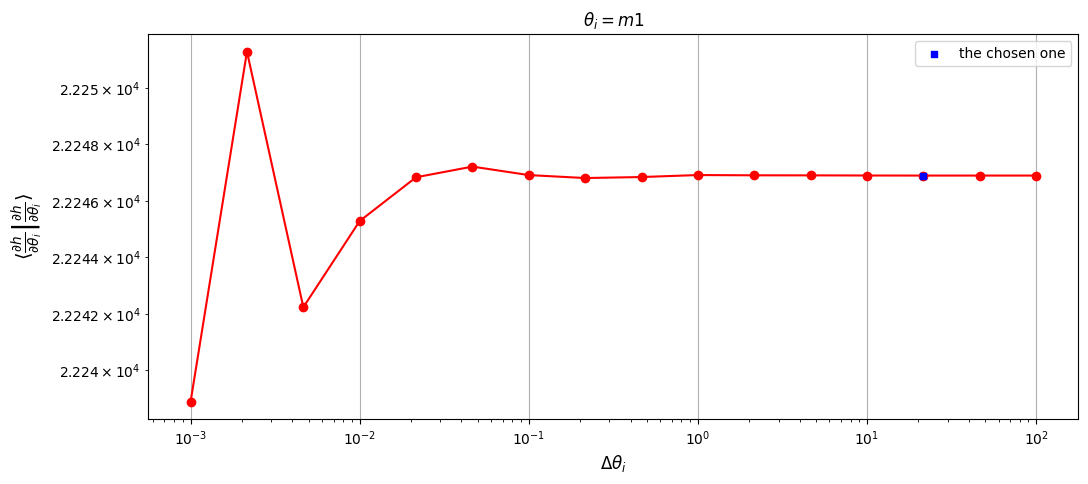

Gamma_ii for m2: 14185045793255.27
Gamma_ii for m2: 14185044620481.74
Gamma_ii for m2: 14185046721536.035
Gamma_ii for m2: 14185044503295.373
Gamma_ii for m2: 14185054279000.383
Gamma_ii for m2: 14185052200996.334
Gamma_ii for m2: 14184961369641.225
Gamma_ii for m2: 14185035451980.502
Gamma_ii for m2: 14185130233120.678
Gamma_ii for m2: 14185461957064.242
Gamma_ii for m2: 14185365078423.637
Gamma_ii for m2: 14184693369375.36
Gamma_ii for m2: 14181781122669.2
Gamma_ii for m2: 14173454362536.904
Gamma_ii for m2: 14193791368163.566
Gamma_ii for m2: 14168605858931.41
[np.float64(8.267675997321229e-08), np.float64(1.4811754491664878e-07), np.float64(1.5637882994262362e-07), np.float64(6.891552769197099e-07), np.float64(1.4649252039285197e-07), np.float64(6.403355831745375e-06), np.float64(5.22256990672522e-06), np.float64(6.681725061253085e-06), np.float64(2.338478257306646e-05), np.float64(6.829478132559595e-06), np.float64(4.735449902128715e-05), np.float64(0.0002053512658931823), np.floa

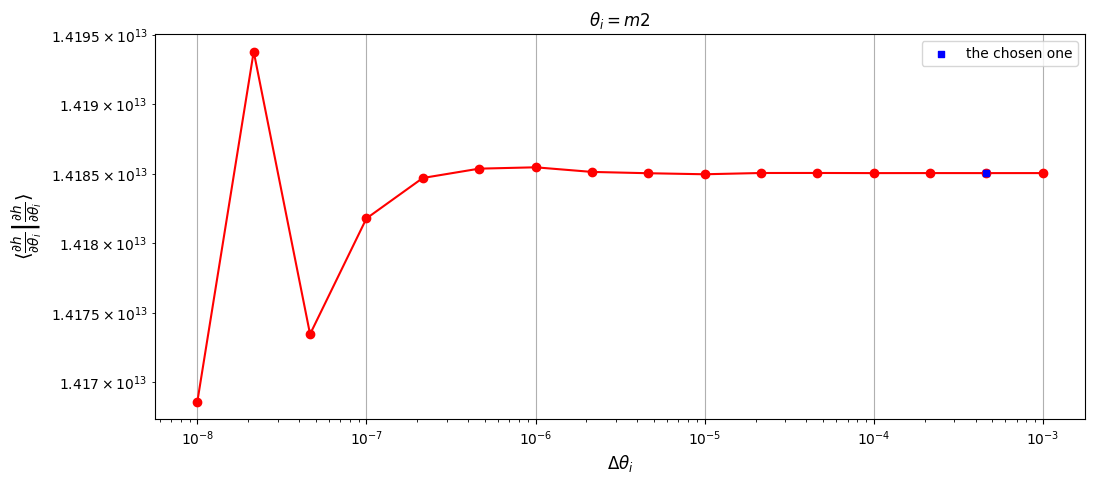

Gamma_ii for a: 1815248042677700.5
Gamma_ii for a: 1815247821010231.2
Gamma_ii for a: 1815248279923799.8
Gamma_ii for a: 1815246475103913.8
Gamma_ii for a: 1815248267550065.0
Gamma_ii for a: 1815251583288523.5
Gamma_ii for a: 1815252453897320.0
Gamma_ii for a: 1815250828757375.2
Gamma_ii for a: 1815222289415366.5
Gamma_ii for a: 1815281048788359.2
Gamma_ii for a: 1815329160738880.8
Gamma_ii for a: 1815793688906601.8
Gamma_ii for a: 1814650413618858.0
Gamma_ii for a: 1815040630613080.5
Gamma_ii for a: 1816612221981168.8
Gamma_ii for a: 1820302777561087.2
[np.float64(1.221141635232133e-07), np.float64(2.528103585473521e-07), np.float64(9.94256102822997e-07), np.float64(9.874385687579585e-07), np.float64(1.8265999539816861e-06), np.float64(4.796075579629797e-07), np.float64(8.952701847063664e-07), np.float64(1.5722229820096438e-05), np.float64(3.2369297873720415e-05), np.float64(2.6503155219473986e-05), np.float64(0.00025582651297831105), np.float64(0.0006300250886691607), np.float64(0.00

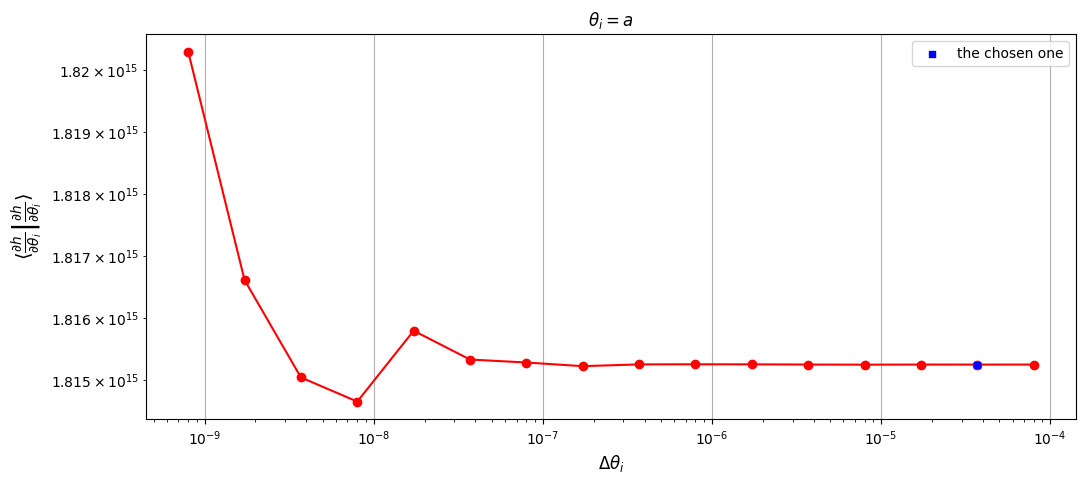

Gamma_ii for p0: 1172653101312323.0
Gamma_ii for p0: 1172653086191227.8
Gamma_ii for p0: 1172653128953071.5
Gamma_ii for p0: 1172653143107410.8
Gamma_ii for p0: 1172653117593530.2
Gamma_ii for p0: 1172653098291654.0
Gamma_ii for p0: 1172652867575194.2
Gamma_ii for p0: 1172653823033827.2
Gamma_ii for p0: 1172653927766907.2
Gamma_ii for p0: 1172658797706183.0
Gamma_ii for p0: 1172678188179041.2
Gamma_ii for p0: 1172658095159897.5
Gamma_ii for p0: 1172642762603499.5
Gamma_ii for p0: 1172843461381810.0
Gamma_ii for p0: 1172415015581243.0
Gamma_ii for p0: 1172271503744731.5
[np.float64(1.2894772911154188e-08), np.float64(3.646589319057818e-08), np.float64(1.2070354591377678e-08), np.float64(2.1757397918626202e-08), np.float64(1.6460005331601803e-08), np.float64(1.967474485668332e-07), np.float64(8.147831987858859e-07), np.float64(8.931286334361572e-08), np.float64(4.152903884127251e-06), np.float64(1.6535203821229016e-05), np.float64(1.713459296165113e-05), np.float64(1.3075215135391007e-05

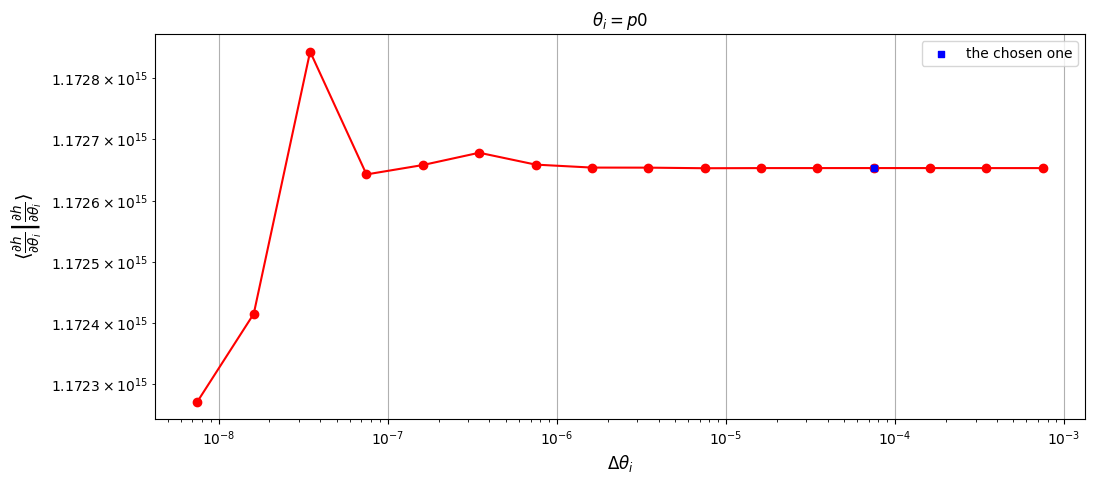

Gamma_ii for e0: 3817522559908868.5
Gamma_ii for e0: 3817522491037662.5
Gamma_ii for e0: 3817523145531645.0
Gamma_ii for e0: 3817520453903421.5
Gamma_ii for e0: 3817523307440442.0
Gamma_ii for e0: 3817518184164071.0
Gamma_ii for e0: 3817510638135272.5
Gamma_ii for e0: 3817602591386169.0
Gamma_ii for e0: 3817523411115367.0
Gamma_ii for e0: 3817725362521220.5
Gamma_ii for e0: 3817224158493088.0
Gamma_ii for e0: 3818361918317965.5
Gamma_ii for e0: 3818035721770184.5
Gamma_ii for e0: 3813958908608430.0
Gamma_ii for e0: 3817100788587620.0
Gamma_ii for e0: 3807744198400607.0
[np.float64(1.8040812113533804e-08), np.float64(1.7144466648907568e-07), np.float64(7.050723777387507e-07), np.float64(7.474838503116378e-07), np.float64(1.3420437372774043e-06), np.float64(1.9766883484536888e-06), np.float64(2.4086648281300498e-05), np.float64(2.0741266594843454e-05), np.float64(5.289835875468307e-05), np.float64(0.00013130065391034267), np.float64(0.0002979706610364208), np.float64(8.543569823641228e-0

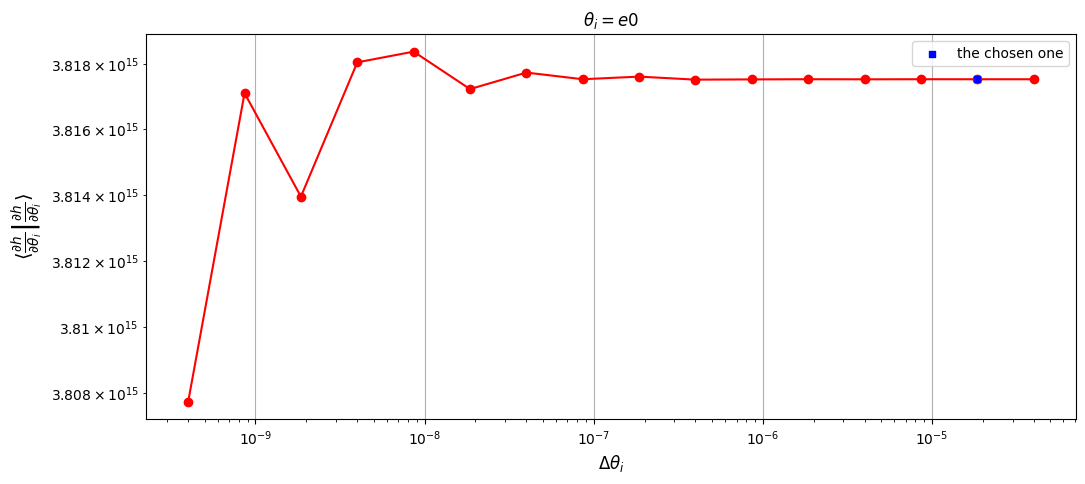

Gamma_ii for qS: 57458.94783534537
Gamma_ii for qS: 57458.94793149193
Gamma_ii for qS: 57458.94793170302
Gamma_ii for qS: 57458.94793170359
Gamma_ii for qS: 57458.94793170246
Gamma_ii for qS: 57458.947931704075
Gamma_ii for qS: 57458.947931702285
Gamma_ii for qS: 57458.94793168984
Gamma_ii for qS: 57458.9479317176
Gamma_ii for qS: 57458.947931744915
Gamma_ii for qS: 57458.94793157778
Gamma_ii for qS: 57458.94793151507
Gamma_ii for qS: 57458.94793175452
Gamma_ii for qS: 57458.947932281386
Gamma_ii for qS: 57458.9479336078
Gamma_ii for qS: 57458.947933819734
[np.float64(1.6733087964725662e-09), np.float64(3.6737547397073105e-12), np.float64(9.877046384157156e-15), np.float64(1.962746396851781e-14), np.float64(2.811159355490859e-14), np.float64(3.1150684750034814e-14), np.float64(2.165352476527279e-13), np.float64(4.830888712250046e-13), np.float64(4.753645144371704e-13), np.float64(2.9087901601406513e-12), np.float64(1.0914136254529466e-12), np.float64(4.167353801311845e-12), np.float64(

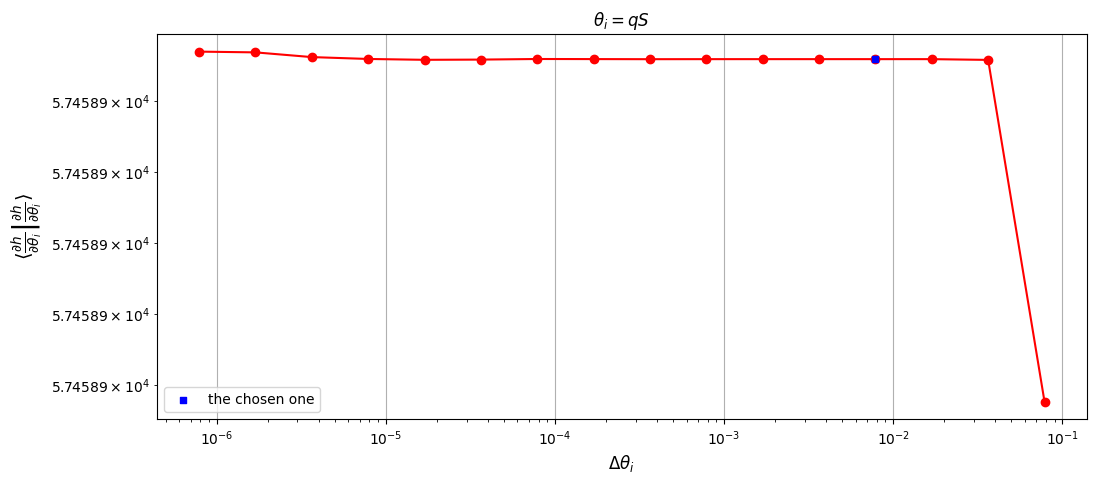

Gamma_ii for phiS: 1108983.0978544678
Gamma_ii for phiS: 1108983.0978177341
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.0978176533
Gamma_ii for phiS: 1108983.097817653
Gamma_ii for phiS: 1108983.0978176533
Gamma_ii for phiS: 1108983.0978176545
Gamma_ii for phiS: 1108983.0978176524
Gamma_ii for phiS: 1108983.0978176494
Gamma_ii for phiS: 1108983.0978176456
Gamma_ii for phiS: 1108983.097817586
Gamma_ii for phiS: 1108983.09781766
[np.float64(3.312376060695232e-11), np.float64(7.306248774304525e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0994967742254377e-16), np.float64(2.0994967742254382e-16), np.float64(2.0994967742254377e-16), np.float64(1.0497483871127179e-15), np.float64(1.8895470968028957e-15), np.float64(2.729345806493079e-15), np.float64(3.3591948387607236e-15), np.float64(

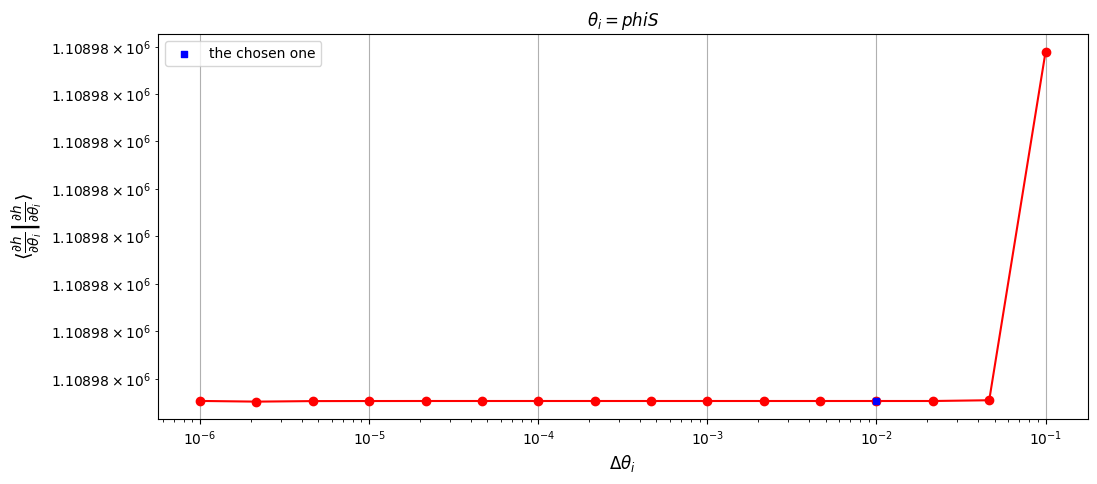

stable deltas: {'m1': 21.544346900318843, 'm2': 0.00046415888336127773, 'a': 3.713271066890227e-05, 'p0': 7.500000000000001e-05, 'e0': 1.8566355334451135e-05, 'qS': 0.007853981633974485, 'phiS': 0.01, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 240.3686215877533 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 16.15679097175598 seconds


In [9]:
evolve_1PA = True
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]


sef_true = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef_true.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher_true = sef_true(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )

In [10]:
# def logmasstransform(Fisher, m1, index_of_m1 = 0):    
#     J = np.eye(len(Fisher))
#     J[index_of_m1,index_of_m1] = m1
    
#     return J.T@Fisher@J
param_true= [m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_0_p,dev_0_e] 
param_0v1_bf = best_fit_0pa_vs_1pa.copy()
param_0v1_bf[0] = np.exp(param_0v1_bf[0])
param_bf = best_fit_with_deviation.copy()
param_bf[0] = np.exp(param_bf[0])

Cov_bf = np.linalg.inv(Fisher_bf)
Cov_0v1_bf = np.linalg.inv(Fisher_0v1_bf)
Cov_true = np.linalg.inv(Fisher_true)

In [11]:
Cov_0v1_bf

array([[ 2.20171743e+02,  1.33153824e-03,  1.49362999e-04,
        -9.07487310e-04, -4.95644167e-05, -2.46122964e-04,
        -3.77347394e-04, -2.00898758e-01,  5.36588605e-02],
       [ 1.33153824e-03,  8.24780125e-09,  9.02585753e-10,
        -5.45437581e-09, -3.06499247e-10, -1.21247699e-09,
        -5.04473563e-09, -1.12501045e-06,  1.51074153e-07],
       [ 1.49362999e-04,  9.02585753e-10,  1.01447325e-10,
        -6.16007216e-10, -3.35207409e-11, -1.59905174e-10,
        -3.31091432e-10, -1.32360038e-07,  3.50272126e-08],
       [-9.07487310e-04, -5.45437581e-09, -6.16007216e-10,
         3.74683217e-09,  2.02943400e-10,  1.04977845e-09,
         1.24895961e-09,  8.34381437e-07, -2.47662637e-07],
       [-4.95644167e-05, -3.06499247e-10, -3.35207409e-11,
         2.02943400e-10,  1.14522872e-11,  5.17719969e-11,
         1.21031723e-10,  4.55008177e-08, -6.99578002e-09],
       [-2.46122964e-04, -1.21247699e-09, -1.59905174e-10,
         1.04977845e-09,  5.17719970e-11,  1.850624

14.834892437808325 87.18908453809112 14.838185291065598


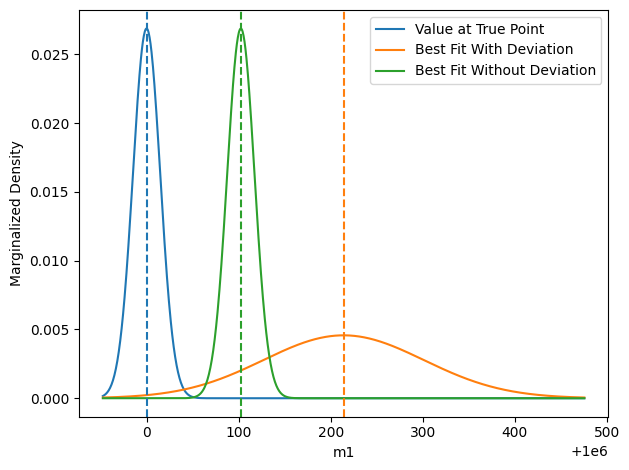

9.078809586835678e-05 0.03969967030133748 9.081740609055284e-05


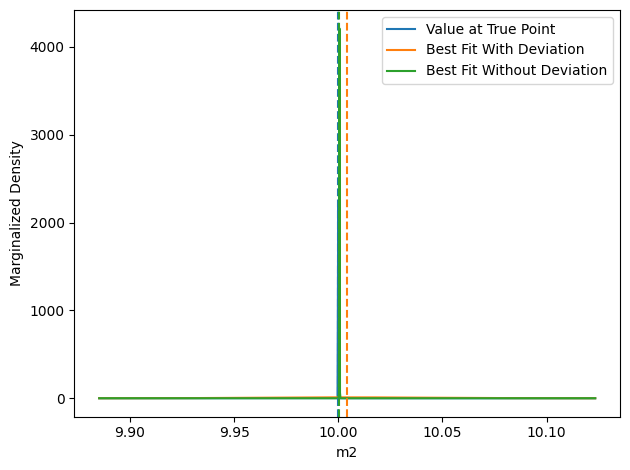

1.0072071113376104e-05 5.0385369203144646e-05 1.0072106263861652e-05


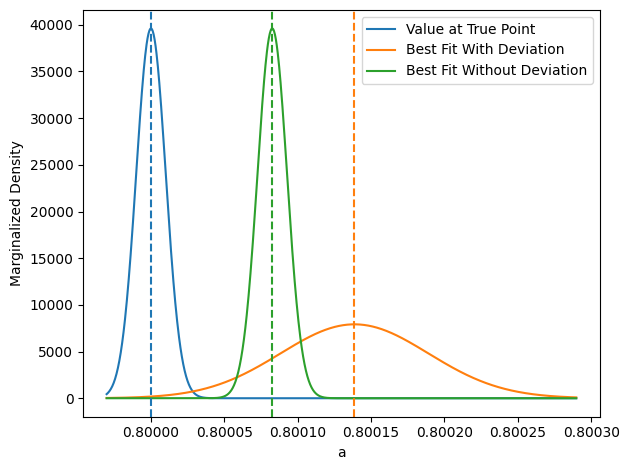

6.12090618499682e-05 0.0002966601129222606 6.121137287784941e-05


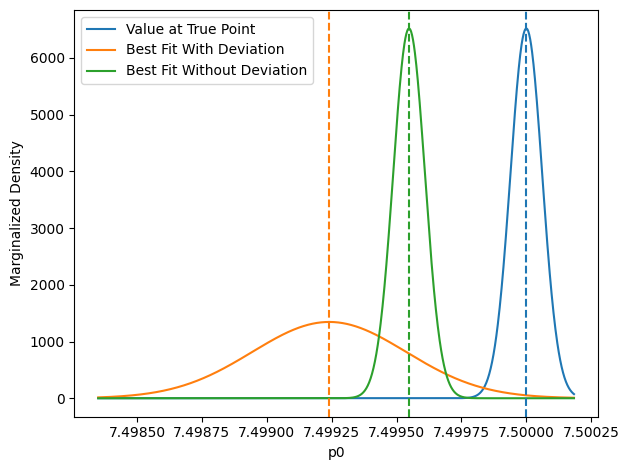

3.3833279902001195e-06 2.8721807182690708e-05 3.3841228150885596e-06


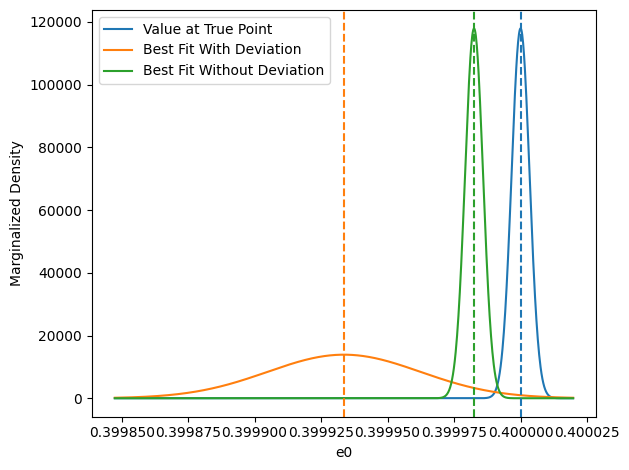

0.013605673155103134 0.014749495316175962 0.013603767325661837


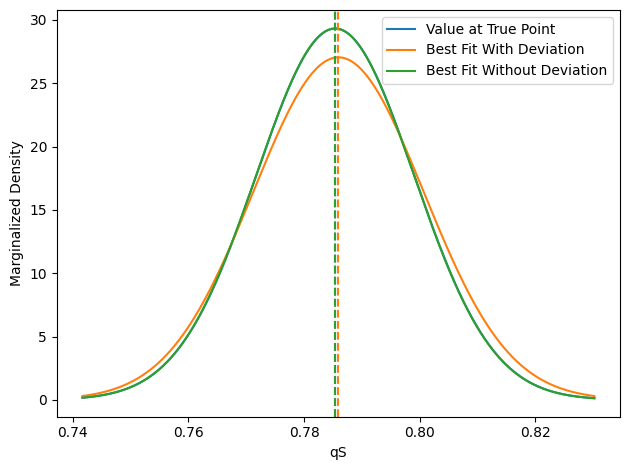

0.017207396270630917 0.01724057591331666 0.01720528356888283


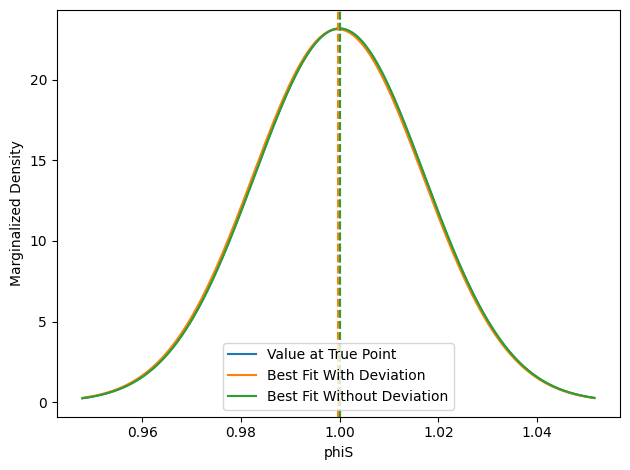

0.07001059695607521 0.07079948221608 0.06999202877423526


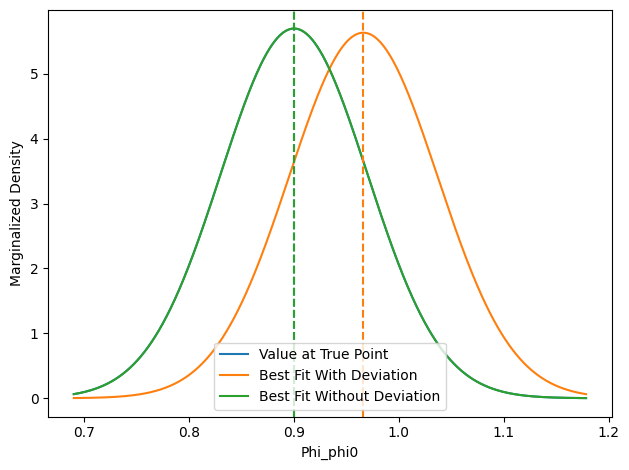

In [12]:
# FOR FIRST EIGHT PARAMETERS ONLY (DOES NOT INCLUDE DEVIATION PARAMETERS)
from scipy.stats import norm

npar = 8
for i in range(npar):

    mu1, sigma1 = param_true[i], np.sqrt(Cov_true[i, i])
    mu2, sigma2 = param_bf[i], np.sqrt(Cov_bf[i, i])
    mu3, sigma3 = param_0v1_bf[i], np.sqrt(Cov_0v1_bf[i, i])

    print(sigma1,sigma2,sigma3)

    # x-range covering all three posteriors
    xmin = min(mu1 - 3*sigma1, mu2 - 3*sigma2, mu3 - 3*sigma3)
    xmax = max(mu1 + 3*sigma1, mu2 + 3*sigma2, mu3 + 3*sigma3)
    x = np.linspace(xmin, xmax, 1000)

    plt.figure()

    line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
    line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
    line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")

    plt.axvline(mu1, linestyle="--", color=line1.get_color())
    plt.axvline(mu2, linestyle="--", color=line2.get_color())
    plt.axvline(mu3, linestyle="--", color=line3.get_color())

    plt.xlabel(param_names[i])
    plt.ylabel("Marginalized Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
npar = 8
for i in range(npar+1,11):

    mu1, sigma1 = param_true[i], np.sqrt(Cov_true[i, i])
    mu2, sigma2 = param_bf[i], np.sqrt(Cov_bf[i, i])

    # x-range covering all three posteriors
    xmin = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
    xmax = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
    x = np.linspace(xmin, xmax, 500)

    plt.figure()


    line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
    line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")

    plt.axvline(mu1, linestyle="--", color=line1.get_color())
    plt.axvline(mu2, linestyle="--", color=line2.get_color())


    plt.xlabel(param_names[i])
    plt.ylabel("Marginalized Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 9

9.078809586835678e-05 0.03969967030133748 9.081740609055284e-05


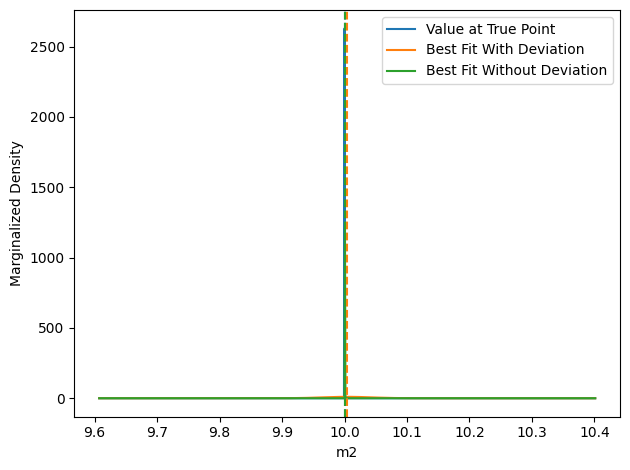

In [11]:
mu1, sigma1 = param_true[1], np.sqrt(Cov_true[1, 1])
mu2, sigma2 = param_bf[1], np.sqrt(Cov_bf[1, 1])
mu3, sigma3 = param_0v1_bf[1], np.sqrt(Cov_0v1_bf[1, 1])
print(sigma1,sigma2,sigma3)
# x-range covering all three posteriors
xmin = min(mu1 - 10*sigma1, mu2 - 10*sigma2, mu3 - 10*sigma3)
xmax = max(mu1 + 10*sigma1, mu2 + 10*sigma2, mu3 + 10*sigma3)
x = np.linspace(xmin, xmax, 1000)
plt.figure()

line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")
plt.axvline(mu1, linestyle="--", color=line1.get_color())
plt.axvline(mu2, linestyle="--", color=line2.get_color())
plt.axvline(mu3, linestyle="--", color=line3.get_color())

plt.xlabel(param_names[1])
plt.ylabel("Marginalized Density")
plt.legend()
plt.tight_layout()
plt.show()

9.078809586835678e-05 0.03969967030133748 9.081740609055284e-05


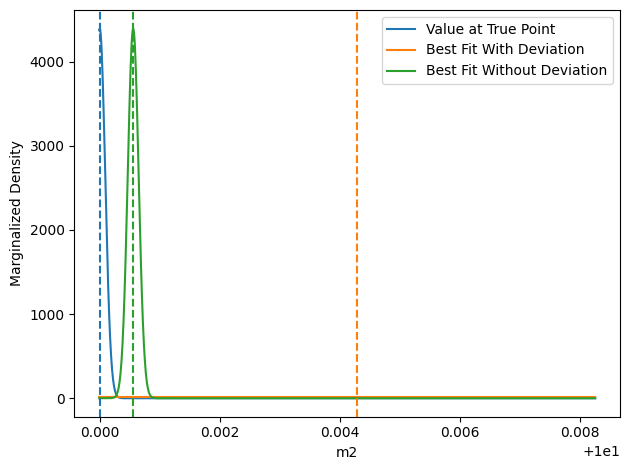

In [14]:
mu1, sigma1 = param_true[1], np.sqrt(Cov_true[1, 1])
mu2, sigma2 = param_bf[1], np.sqrt(Cov_bf[1, 1])
mu3, sigma3 = param_0v1_bf[1], np.sqrt(Cov_0v1_bf[1, 1])
print(sigma1,sigma2,sigma3)
# x-range covering all three posteriors
xmin = min(mu1 - 0.1*sigma1, mu2 - 0.1*sigma2, mu3 - 0.1*sigma3)
xmax = max(mu1 + 0.1*sigma1, mu2 + 0.1*sigma2, mu3 + 0.1*sigma3)
x = np.linspace(xmin, xmax, 1000)
plt.figure()

line1, = plt.plot(x, norm.pdf(x, mu1, sigma1), label="Value at True Point")
line2, = plt.plot(x, norm.pdf(x, mu2, sigma2), label="Best Fit With Deviation")
line3, = plt.plot(x, norm.pdf(x, mu3, sigma3), label="Best Fit Without Deviation")
plt.axvline(mu1, linestyle="--", color=line1.get_color())
plt.axvline(mu2, linestyle="--", color=line2.get_color())
plt.axvline(mu3, linestyle="--", color=line3.get_color())

plt.xlabel(param_names[1])
plt.ylabel("Marginalized Density")
plt.legend()
plt.tight_layout()
plt.show()